# Netflix User Behaviour & Subscription Analytics

## Data Analysis Project

### Objective
Understand how customer behaviour, engagement, subscription characteristics,
and viewing patterns relate to customer retention and churn.

### Analysis Process
Business Understanding → Data Understanding → Data Cleaning →
Exploratory Data Analysis → SQL Analysis → Dashboard → Insights & Recommendations

In [2]:
#Import Libraries

import pandas as pd
import numpy as np
# 2. Load Dataset 
df = pd.read_csv("netflix_large_dataset_cleaned.csv")


In [3]:

df.head()

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
0,U100000,21,Female,Canada,North America,Basic,8.99,2022-03-01,2022-04-19 00:00:00,Bank Transfer,...,2,100,2022-05-23,Night,5,Yes,Trending,54,156,0.35
1,U100001,17,Female,Nigeria,Africa,Basic,8.99,2022-12-02,2026-02-07,Bank Transfer,...,1,86,2023-03-29,Evening,3,No,Trending,55,150,0.49
2,U100002,60,Male,Nigeria,Africa,Standard,13.99,2023-09-01,2026-02-07,Card,...,3,100,2023-09-15,Evening,3,No,Friend,10,245,0.28
3,U100003,60,Male,Nigeria,Africa,Standard,13.99,2024-05-26,2026-02-07,Card,...,3,100,2025-01-31,Afternoon,3,No,Trending,54,285,0.73
4,U100004,50,Female,Canada,North America,Basic,8.99,2023-12-19,2026-02-07,Bank Transfer,...,2,100,2024-06-17,Afternoon,4,Yes,Algorithm,8,139,0.42


In [4]:

df.tail()

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
49995,U149995,40,Female,UK,Europe,Basic,8.99,2022-03-29,2023-05-09 00:00:00,Bank Transfer,...,1,91,2022-06-01,Night,3,No,Algorithm,25,196,0.54
49996,U149996,17,Male,USA,North America,Standard,13.99,2022-07-20,2026-02-07,Card,...,2,92,2022-12-31,Afternoon,2,No,Search,24,241,0.93
49997,U149997,17,Male,Brazil,South America,Standard,13.99,2024-06-07,2026-02-07,Card,...,3,100,2024-08-05,Night,3,No,Ads,4,272,0.58
49998,U149998,21,Female,South Africa,Africa,Premium,17.99,2023-02-05,2026-02-07,Card,...,4,100,2023-09-11,Afternoon,4,Yes,Search,38,341,0.86
49999,U149999,40,Male,Brazil,South America,Basic,8.99,2023-08-19,2026-02-07,Card,...,1,81,2024-05-30,Morning,2,No,Algorithm,17,208,0.55


# 1. Business Understanding

## Business Problem

Netflix wants to better understand how customer behaviour and subscription
characteristics relate to customer engagement, retention, and churn.

## Business Objectives

1. Understand the characteristics of Netflix's customer base.
2. Analyse customer engagement and viewing behaviour.
3. Compare behaviour across subscription plans.
4. Identify factors associated with customer churn.
5. Identify valuable customer segments.
6. Provide data-driven recommendations to improve customer retention.

## Key Business Questions

1. Which subscription plans are most popular?
2. How does engagement differ between subscription plans?
3. What factors are associated with higher engagement?
4. Are highly engaged customers less likely to churn?
5. Which customer characteristics are associated with churn?
6. Does subscription plan influence churn?
7. Which customer segments have the highest engagement?
8. Which customer segments may require retention strategies?

## Key KPIs

- Total customers
- Churn rate
- Average monthly fee
- Average watch time
- Average weekly watch time
- Average session count
- Average completion rate
- Average rating
- Average days since last watch
- Content diversity score

## Stakeholders

- Senior Management
- Customer Retention Team
- Marketing Team
- Subscription/Pricing Team
- Content Team
- Product Team

# 2. Data Understanding

In [5]:
df.sample(5, random_state=42)

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
33553,U133553,40,Male,South Africa,Africa,Basic,8.99,2022-05-17,2026-02-07,Wallet,...,1,65,2022-07-01,Morning,3,No,Ads,12,178,0.49
9427,U109427,21,Female,South Africa,Africa,Basic,8.99,2023-07-17,2026-02-07,Wallet,...,2,100,2024-04-08,Morning,3,No,Ads,38,169,0.29
199,U100199,21,Female,South Africa,Africa,Standard,13.99,2023-10-13,2026-02-07,Bank Transfer,...,3,100,2024-01-15,Morning,5,Yes,Algorithm,44,192,0.67
12447,U112447,40,Female,South Africa,Africa,Basic,8.99,2022-07-04,2026-02-07,Bank Transfer,...,1,91,2022-11-10,Morning,4,Yes,Trending,42,159,0.91
39489,U139489,50,Female,Germany,Europe,Basic,8.99,2022-04-11,2026-02-07,Card,...,1,55,2022-06-13,Afternoon,3,No,Search,33,288,0.72


In [6]:
df.shape

(50000, 29)

In [7]:
df.describe()

,age_group,monthly_fee,release_year,watch_time_minutes,session_count,completion_percentage,rating,days_since_last_watch,avg_weekly_watch_time,content_diversity_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,36.412180,12.990900,2011.534020,84.999620,2.358740,91.915480,3.417980,29.938080,256.341400,0.601056
std,15.313068,3.610202,6.963695,28.086897,0.966408,11.953255,1.015861,17.621492,81.632833,0.230076
min,17.000000,8.990000,2000.000000,10.000000,1.000000,20.000000,1.000000,0.000000,33.000000,0.200000
25%,21.000000,8.990000,2006.000000,63.000000,2.000000,87.000000,3.000000,15.000000,191.000000,0.400000
50%,40.000000,13.990000,2011.000000,83.000000,2.000000,99.000000,3.000000,30.000000,251.000000,0.600000
75%,50.000000,17.990000,2018.000000,106.000000,3.000000,100.000000,4.000000,45.000000,318.250000,0.800000
max,60.000000,17.990000,2025.000000,180.000000,6.000000,100.000000,5.000000,60.000000,499.000000,1.000000


In [8]:
# Data quality Assessment 
df.nunique().sort_values()

gender                         2
content_type                   2
discount_applied               2
churn_status                   2
liked                          2
payment_method                 3
monthly_fee                    3
subscription_plan              3
device_type                    4
time_of_day                    4
rating                         5
recommendation_source          5
region                         5
age_group                      6
session_count                  6
language                       7
genre                          8
country                       10
release_year                  26
days_since_last_watch         61
completion_percentage         72
content_diversity_score       81
watch_time_minutes           162
avg_weekly_watch_time        444
subscription_start_date      901
date_watched                1191
subscription_end_date       1336
title                      20987
user_id                    50000
dtype: int64

In [9]:
df.isnull().sum()

user_id                    0
age_group                  0
gender                     0
country                    0
region                     0
subscription_plan          0
monthly_fee                0
subscription_start_date    0
subscription_end_date      0
payment_method             0
discount_applied           0
churn_status               0
title                      0
content_type               0
genre                      0
language                   0
release_year               0
device_type                0
watch_time_minutes         0
session_count              0
completion_percentage      0
date_watched               0
time_of_day                0
rating                     0
liked                      0
recommendation_source      0
days_since_last_watch      0
avg_weekly_watch_time      0
content_diversity_score    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["user_id"].nunique()

50000

In [12]:
len(df)

50000

In [13]:
df["subscription_plan"].value_counts()

subscription_plan
Basic       20031
Standard    17419
Premium     12550
Name: count, dtype: int64

In [14]:
df["churn_status"].value_counts()

churn_status
Active       41391
Cancelled     8609
Name: count, dtype: int64

In [15]:
df["genre"].value_counts()

genre
Thriller       6405
Drama          6390
Documentary    6264
Animation      6240
Comedy         6211
Sci-Fi         6207
Romance        6185
Action         6098
Name: count, dtype: int64

In [16]:
df["device_type"].value_counts()

device_type
TV        17036
Mobile    15104
Laptop    11497
Tablet     6363
Name: count, dtype: int64

In [17]:
df.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
age_group,50000.0,36.412180,15.313068,17.00,21.00,40.00,50.00,60.00
monthly_fee,50000.0,12.990900,3.610202,8.99,8.99,13.99,17.99,17.99
release_year,50000.0,2011.534020,6.963695,2000.00,2006.00,2011.00,2018.00,2025.00
watch_time_minutes,50000.0,84.999620,28.086897,10.00,63.00,83.00,106.00,180.00
session_count,50000.0,2.358740,0.966408,1.00,2.00,2.00,3.00,6.00
completion_percentage,50000.0,91.915480,11.953255,20.00,87.00,99.00,100.00,100.00
rating,50000.0,3.417980,1.015861,1.00,3.00,3.00,4.00,5.00
days_since_last_watch,50000.0,29.938080,17.621492,0.00,15.00,30.00,45.00,60.00
avg_weekly_watch_time,50000.0,256.341400,81.632833,33.00,191.00,251.00,318.25,499.00
content_diversity_score,50000.0,0.601056,0.230076,0.20,0.40,0.60,0.80,1.00


In [18]:
df[
    (df["completion_percentage"] < 0 )|
    (df["completion_percentage"]> 100)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [19]:
df[
    (df["rating"] < 1) |
    (df["rating"] > 5)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [20]:
df[df["monthly_fee"] <= 0]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [21]:
df[df["session_count"] <= 0]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [22]:
df[
    (df["content_diversity_score"] < 0) |
    (df["content_diversity_score"] > 1)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


# 3. Data Cleaning

In [23]:
df_clean = df.copy()

In [24]:
# Standardise column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [25]:
df_clean.columns.tolist()

['user_id',
 'age_group',
 'gender',
 'country',
 'region',
 'subscription_plan',
 'monthly_fee',
 'subscription_start_date',
 'subscription_end_date',
 'payment_method',
 'discount_applied',
 'churn_status',
 'title',
 'content_type',
 'genre',
 'language',
 'release_year',
 'device_type',
 'watch_time_minutes',
 'session_count',
 'completion_percentage',
 'date_watched',
 'time_of_day',
 'rating',
 'liked',
 'recommendation_source',
 'days_since_last_watch',
 'avg_weekly_watch_time',
 'content_diversity_score']

In [26]:
date_columns = [
    "subscription_start_date",
    "subscription_end_date",
    "date_watched"
]

for column in date_columns:
    df_clean[column] = pd.to_datetime(
        df_clean[column],
        errors="coerce",
        format="mixed"
    )

In [27]:
df_clean[date_columns].dtypes

subscription_start_date    datetime64[ns]
subscription_end_date      datetime64[ns]
date_watched               datetime64[ns]
dtype: object

## 3.2 Missing Values

In [28]:
missing_values = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": df_clean.isnull().mean() * 100
})

missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
user_id,0,0.0
age_group,0,0.0
gender,0,0.0
country,0,0.0
region,0,0.0
subscription_plan,0,0.0
monthly_fee,0,0.0
subscription_start_date,0,0.0
subscription_end_date,0,0.0
payment_method,0,0.0


In [29]:
df_clean.isnull().sum().sum()

np.int64(0)

## 3.3 Duplicate Records

In [30]:
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate user IDs:", df_clean["user_id"].duplicated().sum())

Duplicate rows: 0
Duplicate user IDs: 0


## 3.4 Categorical Value Validation

In [31]:
categorical_columns = [
    "gender",
    "country",
    "region",
    "subscription_plan",
    "payment_method",
    "discount_applied",
    "churn_status",
    "content_type",
    "genre",
    "language",
    "device_type",
    "time_of_day",
    "liked",
    "recommendation_source"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts(dropna=False))


--- gender ---
gender
Male      25015
Female    24985
Name: count, dtype: int64

--- country ---
country
USA             5095
Canada          5077
France          5064
Germany         5008
South Africa    5006
UK              4966
India           4963
Japan           4953
Nigeria         4937
Brazil          4931
Name: count, dtype: int64

--- region ---
region
Europe           15038
North America    10172
Africa            9943
Asia              9916
South America     4931
Name: count, dtype: int64

--- subscription_plan ---
subscription_plan
Basic       20031
Standard    17419
Premium     12550
Name: count, dtype: int64

--- payment_method ---
payment_method
Bank Transfer    16701
Card             16670
Wallet           16629
Name: count, dtype: int64

--- discount_applied ---
discount_applied
No     35099
Yes    14901
Name: count, dtype: int64

--- churn_status ---
churn_status
Active       41391
Cancelled     8609
Name: count, dtype: int64

--- content_type ---
content_type
Series

## 3.5 Numerical Value Validation

In [32]:
df_clean["age_group"].describe()

count    50000.000000
mean        36.412180
std         15.313068
min         17.000000
25%         21.000000
50%         40.000000
75%         50.000000
max         60.000000
Name: age_group, dtype: float64

In [33]:
df_clean[
    (df_clean["age_group"] < 13) |
    (df_clean["age_group"] > 100)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [34]:
df_clean[
    df_clean["monthly_fee"] <= 0
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [35]:
df_clean[
    df_clean["watch_time_minutes"] < 0
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [36]:
df_clean[
    df_clean["session_count"] < 0
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [37]:
df_clean[
    (df_clean["completion_percentage"] < 0) |
    (df_clean["completion_percentage"] > 100)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [38]:
df_clean[
    (df_clean["rating"] < 1) |
    (df_clean["rating"] > 5)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [39]:
df_clean[
    df_clean["days_since_last_watch"] < 0
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


In [40]:
df_clean[
    (df_clean["content_diversity_score"] < 0) |
    (df_clean["content_diversity_score"] > 1)
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,session_count,completion_percentage,date_watched,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score


## 3.6 Date & Business Logic Validation

In [41]:
invalid_subscription_dates = df_clean[
    df_clean["subscription_end_date"] <
    df_clean["subscription_start_date"]
]

invalid_subscription_dates.shape

(0, 29)

In [42]:
df_clean["watch_after_subscription_end"] = (
    df_clean["date_watched"] >
    df_clean["subscription_end_date"]
)

In [43]:
df_clean["is_placeholder_end_date"] = (
    df_clean["subscription_end_date"] == "2026-02-07"
)

In [44]:
df_clean["watch_after_subscription_end"].value_counts()

watch_after_subscription_end
False    48176
True      1824
Name: count, dtype: int64

In [45]:
df_clean["days_after_subscription_end"] = (
    df_clean["date_watched"] -
    df_clean["subscription_end_date"]
).dt.days

In [46]:
df_clean[
    df_clean["watch_after_subscription_end"]
]["days_after_subscription_end"].describe()

count    1824.000000
mean       90.351974
std        63.256472
min         1.000000
25%        37.000000
50%        79.000000
75%       136.000000
max       259.000000
Name: days_after_subscription_end, dtype: float64

In [47]:
df_clean[
    df_clean["watch_after_subscription_end"]
][[
    "user_id",
    "subscription_start_date",
    "subscription_end_date",
    "date_watched",
    "churn_status",
    "subscription_plan"
]].head(20)

,user_id,subscription_start_date,subscription_end_date,date_watched,churn_status,subscription_plan
0,U100000,2022-03-01,2022-04-19,2022-05-23,Cancelled,Basic
46,U100046,2024-05-25,2024-07-12,2024-10-27,Cancelled,Basic
69,U100069,2024-06-06,2025-02-16,2025-02-18,Cancelled,Basic
73,U100073,2024-01-24,2024-05-11,2024-11-06,Cancelled,Basic
89,U100089,2022-11-17,2023-04-09,2023-09-02,Cancelled,Basic
98,U100098,2022-11-13,2023-02-10,2023-04-11,Cancelled,Basic
110,U100110,2023-07-07,2023-12-12,2024-03-20,Cancelled,Premium
120,U100120,2022-08-11,2022-12-27,2022-12-31,Cancelled,Premium
121,U100121,2023-03-16,2023-05-05,2023-10-26,Cancelled,Basic
128,U100128,2022-03-09,2022-07-21,2022-11-06,Cancelled,Standard


In [48]:
pd.crosstab(
    df_clean["watch_after_subscription_end"],
    df_clean["churn_status"],
    normalize="index"
) * 100

churn_status,Active,Cancelled
watch_after_subscription_end,,
False,85.916224,14.083776
True,0.000000,100.000000


In [49]:
df_clean[
    df_clean["watch_after_subscription_end"]
]["days_after_subscription_end"].describe()

count    1824.000000
mean       90.351974
std        63.256472
min         1.000000
25%        37.000000
50%        79.000000
75%       136.000000
max       259.000000
Name: days_after_subscription_end, dtype: float64

### Data Quality Finding: Viewing After Subscription End

1,824 records contain a `date_watched` value that occurs after the recorded
`subscription_end_date`.

The difference ranges from 1 to 259 days, with a median of 79 days.

Because the dataset does not provide sufficient information to determine
whether these records are incorrect or whether the subscription dates have a
different business definition, the records will not be deleted or modified.

Instead, the inconsistency will be retained as a data-quality flag and
considered when interpreting subscription and viewing behaviour.

### Data Quality Finding: Placeholder Subscription End Date

`subscription_end_date` is a real, varied date only for customers with
`churn_status == "Cancelled"`. Every customer with `churn_status == "Active"`
(41,391 rows) shares the exact same `subscription_end_date` value of
`2026-02-07`, which is a data-snapshot placeholder, not a true end date.

This does not affect the "viewing after subscription end" check above, since
all watch activity in the dataset predates the snapshot date. However, this
column should not be used to calculate subscription duration or tenure
without first separating Active and Cancelled customers, or tenure for
Active users will be misleadingly measured against the snapshot date
instead of a real end date. The `is_placeholder_end_date` flag above marks
these rows explicitly.

In [50]:
pd.crosstab(
    df_clean["watch_after_subscription_end"],
    df_clean["churn_status"],
    normalize="index"
) * 100

churn_status,Active,Cancelled
watch_after_subscription_end,,
False,85.916224,14.083776
True,0.000000,100.000000


In [51]:
df_clean[date_columns].info()
df_clean[date_columns].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subscription_start_date  50000 non-null  datetime64[ns]
 1   subscription_end_date    50000 non-null  datetime64[ns]
 2   date_watched             50000 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 1.1 MB


,subscription_start_date,subscription_end_date,date_watched
min,2022-01-01,2022-02-07,2022-01-05
max,2024-06-19,2026-02-07,2025-04-14


In [52]:
df_clean[
    df_clean["subscription_end_date"] < df_clean["subscription_start_date"]
]

,user_id,age_group,gender,country,region,subscription_plan,monthly_fee,subscription_start_date,subscription_end_date,payment_method,...,time_of_day,rating,liked,recommendation_source,days_since_last_watch,avg_weekly_watch_time,content_diversity_score,watch_after_subscription_end,is_placeholder_end_date,days_after_subscription_end


In [53]:
df_clean[
    df_clean["date_watched"] > df_clean["subscription_end_date"]
].shape

(1824, 32)

In [54]:
quality_report = pd.DataFrame({
    "column": df_clean.columns,
    "data_type": df_clean.dtypes.astype(str),
    "missing_values": df_clean.isnull().sum(),
    "missing_percentage": df_clean.isnull().mean() * 100,
    "unique_values": df_clean.nunique(),
    "duplicate_values": [
        df_clean[column].duplicated().sum()
        for column in df_clean.columns
    ]
})

quality_report

,column,data_type,missing_values,missing_percentage,unique_values,duplicate_values
user_id,user_id,object,0,0.0,50000,0
age_group,age_group,int64,0,0.0,6,49994
gender,gender,object,0,0.0,2,49998
country,country,object,0,0.0,10,49990
region,region,object,0,0.0,5,49995
subscription_plan,subscription_plan,object,0,0.0,3,49997
monthly_fee,monthly_fee,float64,0,0.0,3,49997
subscription_start_date,subscription_start_date,datetime64[ns],0,0.0,901,49099
subscription_end_date,subscription_end_date,datetime64[ns],0,0.0,1336,48664
payment_method,payment_method,object,0,0.0,3,49997


In [55]:
quality_report.sort_values(
    "missing_percentage",
    ascending=False
)

,column,data_type,missing_values,missing_percentage,unique_values,duplicate_values
user_id,user_id,object,0,0.0,50000,0
age_group,age_group,int64,0,0.0,6,49994
gender,gender,object,0,0.0,2,49998
country,country,object,0,0.0,10,49990
region,region,object,0,0.0,5,49995
subscription_plan,subscription_plan,object,0,0.0,3,49997
monthly_fee,monthly_fee,float64,0,0.0,3,49997
subscription_start_date,subscription_start_date,datetime64[ns],0,0.0,901,49099
subscription_end_date,subscription_end_date,datetime64[ns],0,0.0,1336,48664
payment_method,payment_method,object,0,0.0,3,49997


In [56]:
df_clean.to_csv("netflix_cleaned_final.csv", index=False)

# 4. Initial Findings

### Dataset Overview

- The dataset contains 50,000 customer records and 29 variables.
- The dataset covers demographics, subscriptions, payments, viewing behaviour,
  engagement and churn.
- Each customer has a unique user ID.

### Data Quality

- No missing values were identified.
- No completely duplicated records were identified.
- Numerical variables generally fall within reasonable ranges.
- Date columns require standardisation.
- Records where viewing activity occurs after the recorded subscription end
  date require further investigation.
- The `age_group` column requires clarification because it contains numerical
  age values rather than age ranges.
- `subscription_end_date` is a real date only for `Cancelled` users. For
  `Active` users it is always `2026-02-07`, a snapshot placeholder rather
  than a true end date, and must be treated accordingly in any tenure or
  duration calculations.

# 5. Exploratory Data Analysis

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 5.1 Customer Base Overview
Understanding who the customers are before relating anything to churn.

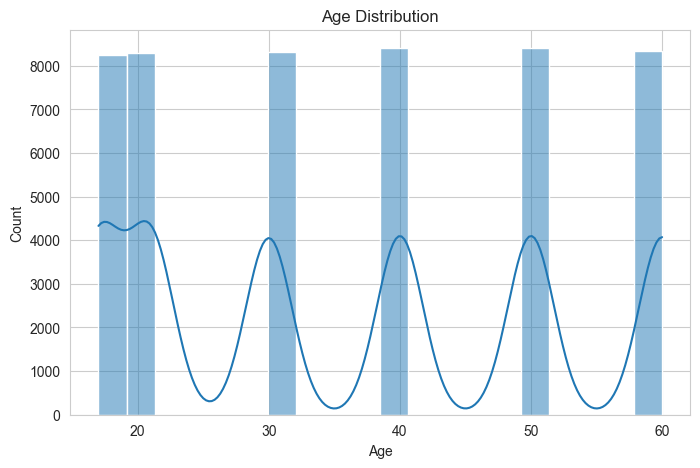

In [58]:
sns.histplot(df_clean["age_group"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

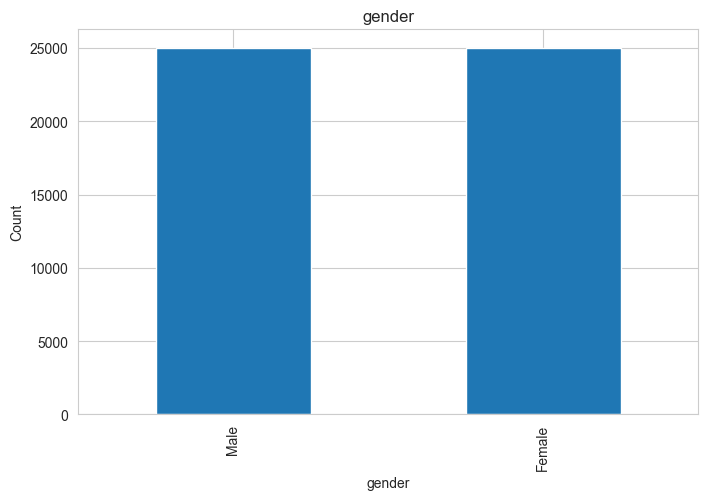

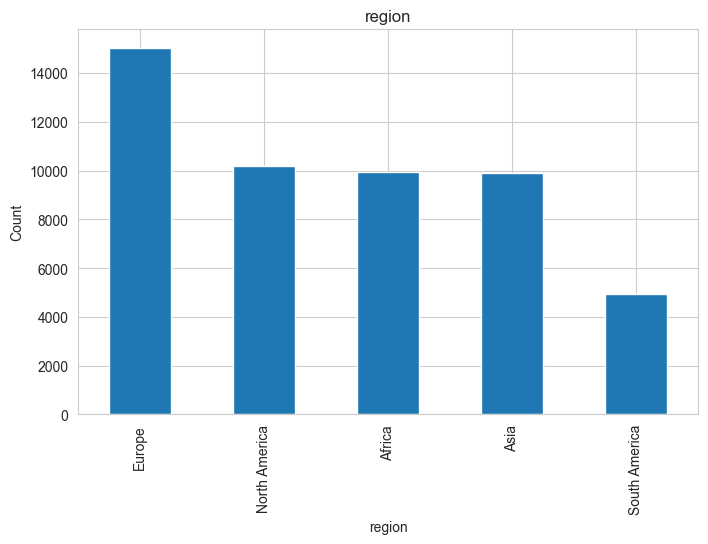

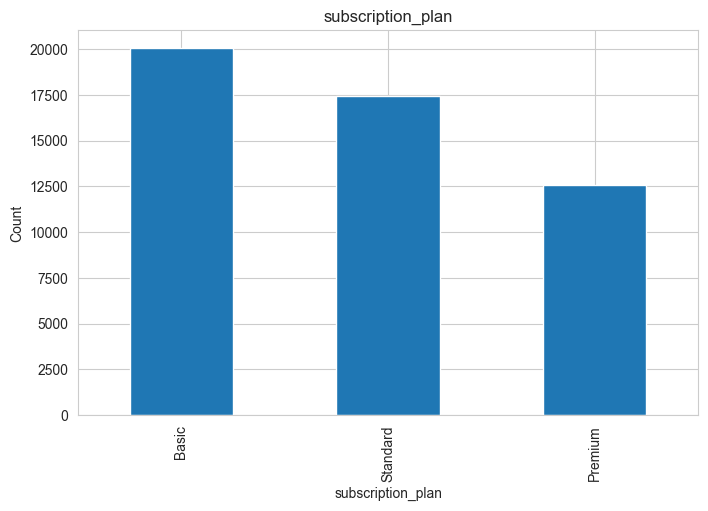

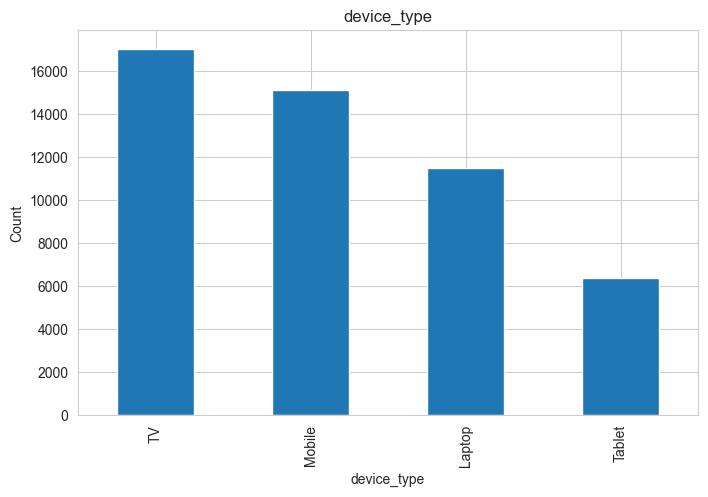

In [59]:
categorical_vars = ["gender", "region", "subscription_plan", "device_type"]

for col in categorical_vars:
    df_clean[col].value_counts().plot(kind="bar", title=col)
    plt.ylabel("Count")
    plt.show()

## 5.2 Churn Rate by Segment
Which customer segments churn more than others?

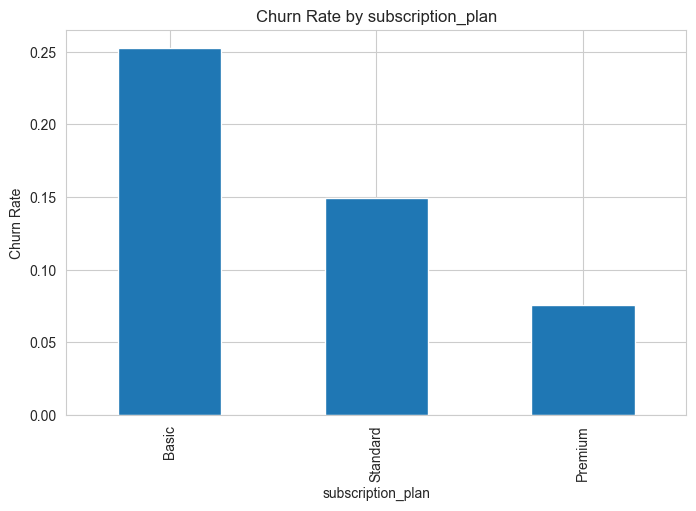

subscription_plan
Basic       0.252259
Standard    0.149549
Premium     0.075777
Name: Cancelled, dtype: float64



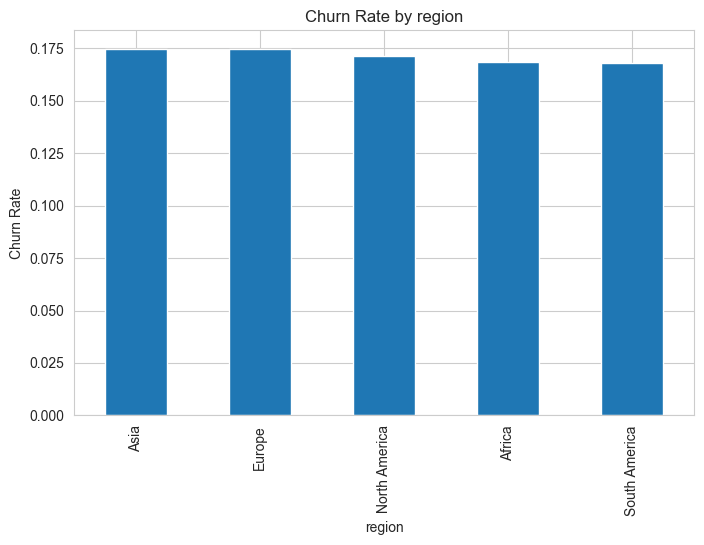

region
Asia             0.174869
Europe           0.174558
North America    0.171549
Africa           0.168561
South America    0.168120
Name: Cancelled, dtype: float64



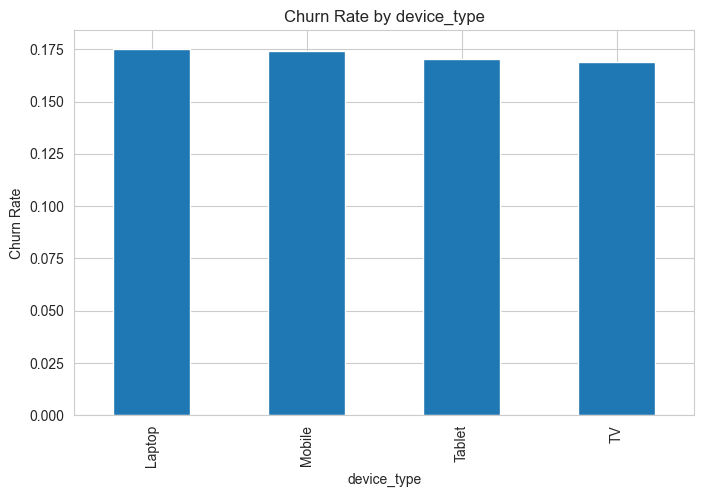

device_type
Laptop    0.175263
Mobile    0.174192
Tablet    0.170517
TV        0.168936
Name: Cancelled, dtype: float64



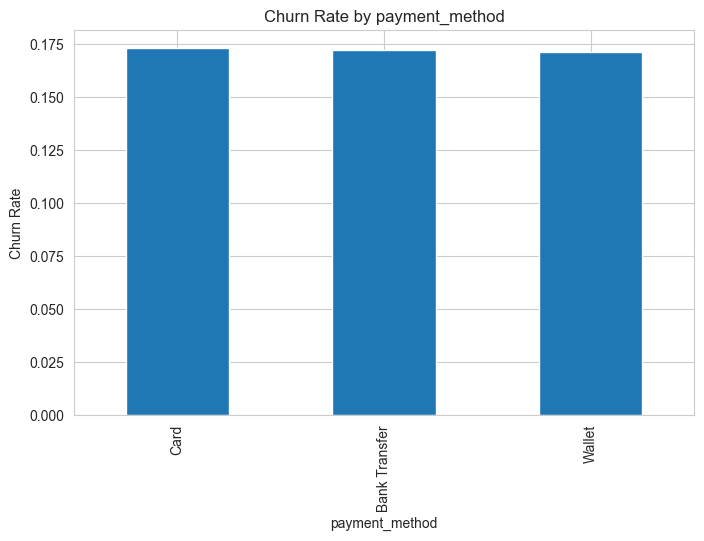

payment_method
Card             0.173065
Bank Transfer    0.172145
Wallet           0.171327
Name: Cancelled, dtype: float64



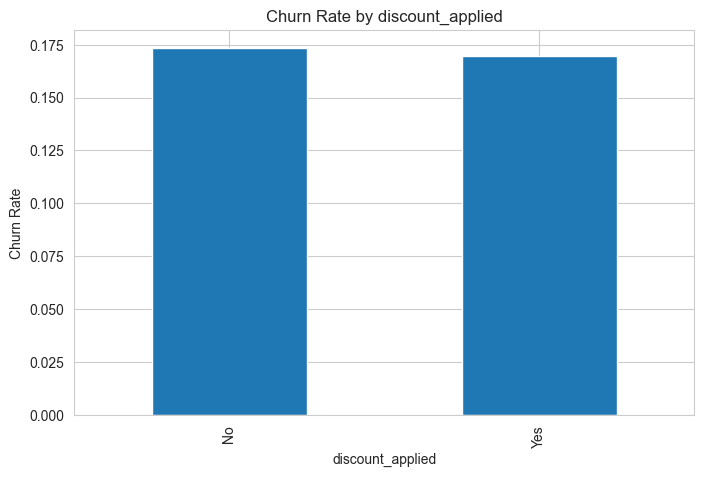

discount_applied
No     0.173253
Yes    0.169653
Name: Cancelled, dtype: float64



In [60]:
def churn_rate_by(column):
    rate = (
        df_clean.groupby(column)["churn_status"]
        .value_counts(normalize=True)
        .unstack()["Cancelled"]
        .sort_values(ascending=False)
    )
    rate.plot(kind="bar", title=f"Churn Rate by {column}")
    plt.ylabel("Churn Rate")
    plt.show()
    return rate

for col in ["subscription_plan", "region", "device_type", "payment_method", "discount_applied"]:
    print(churn_rate_by(col))
    print()

## 5.3 Engagement Behaviour vs. Churn
Do churned users show weaker engagement before cancelling?

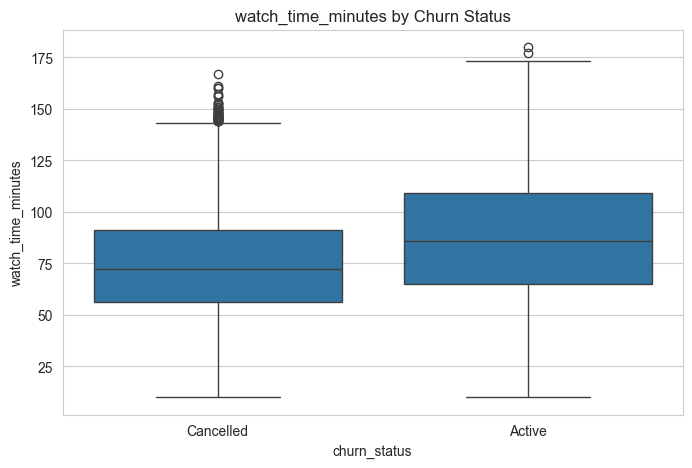

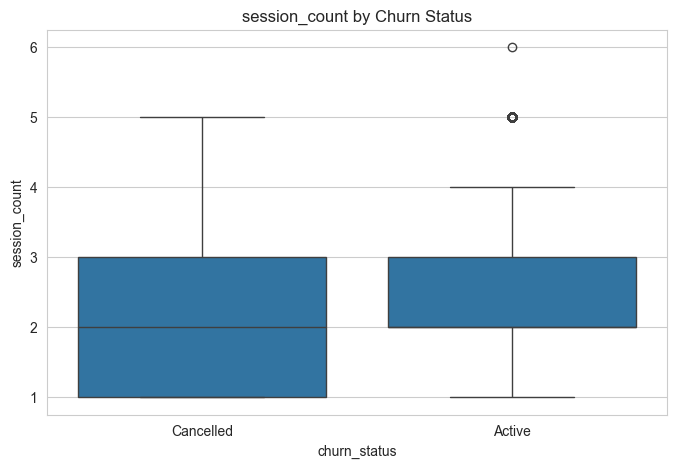

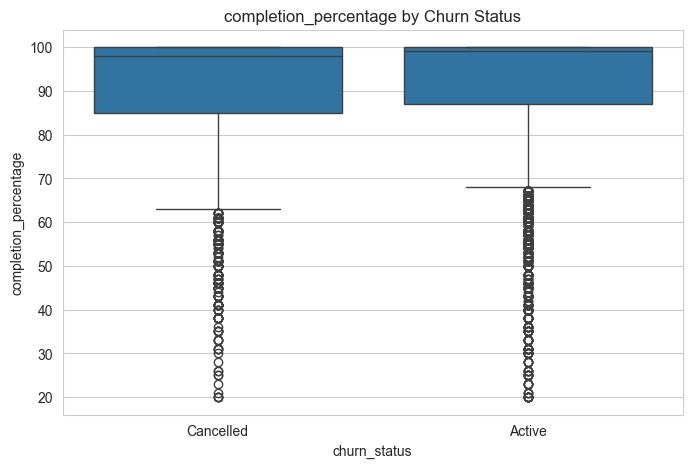

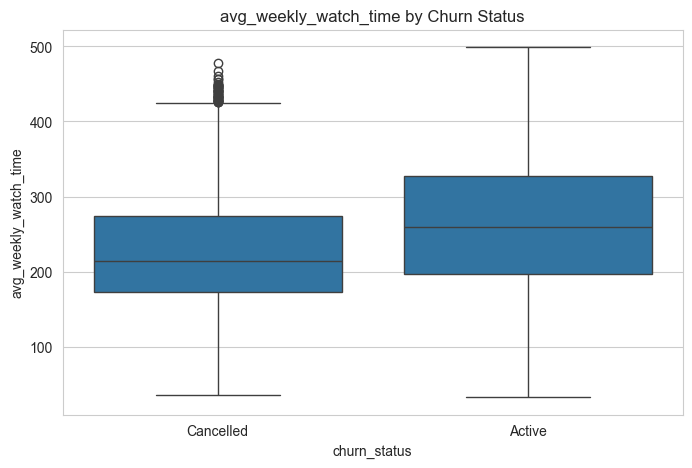

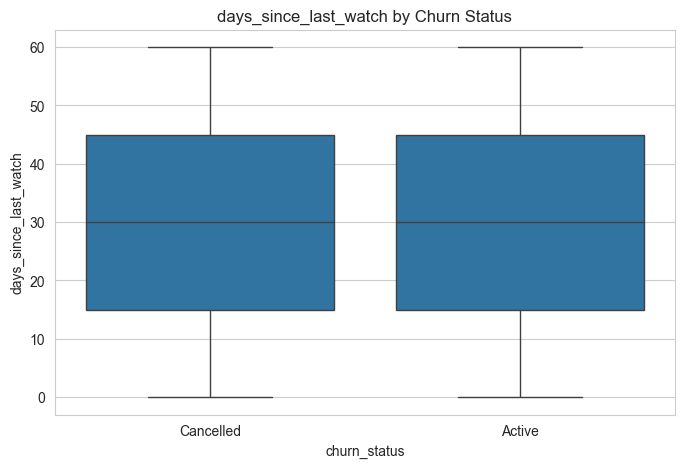

,watch_time_minutes,session_count,completion_percentage,avg_weekly_watch_time,days_since_last_watch
churn_status,,,,,
Active,87.065860,2.427388,92.111063,262.455413,29.938489
Cancelled,75.065397,2.028691,90.975142,226.945987,29.936113


In [61]:
engagement_vars = [
    "watch_time_minutes",
    "session_count",
    "completion_percentage",
    "avg_weekly_watch_time",
    "days_since_last_watch",
]

for col in engagement_vars:
    sns.boxplot(data=df_clean, x="churn_status", y=col)
    plt.title(f"{col} by Churn Status")
    plt.show()

df_clean.groupby("churn_status")[engagement_vars].mean()

## 5.4 Content Preferences & Satisfaction vs. Churn

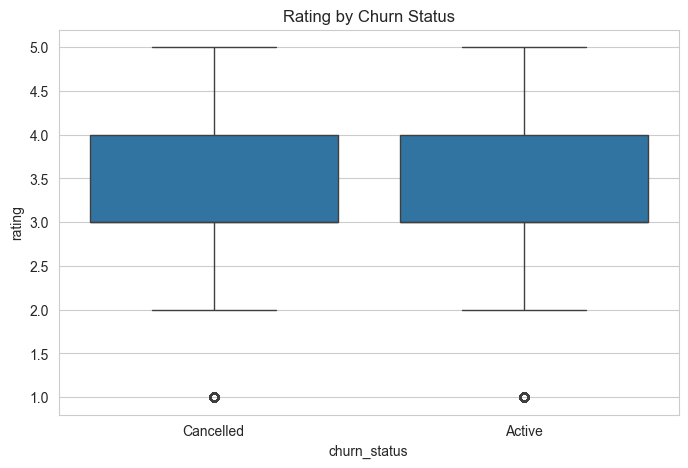

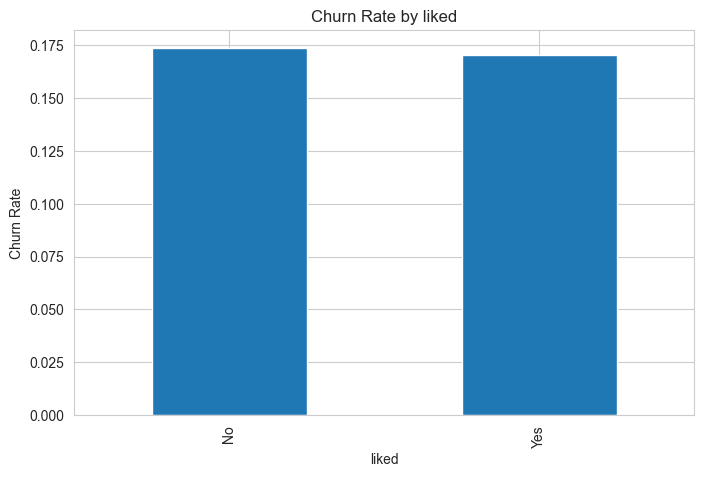

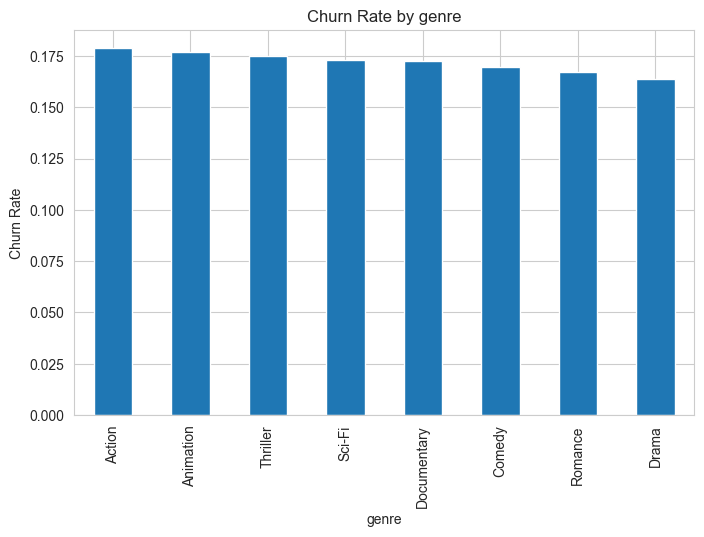

genre
Action         0.178747
Animation      0.177083
Thriller       0.175176
Sci-Fi         0.173192
Documentary    0.172573
Comedy         0.169860
Romance        0.167179
Drama          0.163850
Name: Cancelled, dtype: float64

In [62]:
sns.boxplot(data=df_clean, x="churn_status", y="rating")
plt.title("Rating by Churn Status")
plt.show()

churn_rate_by("liked")
churn_rate_by("genre")

## 5.5 Correlation Between Numeric Features

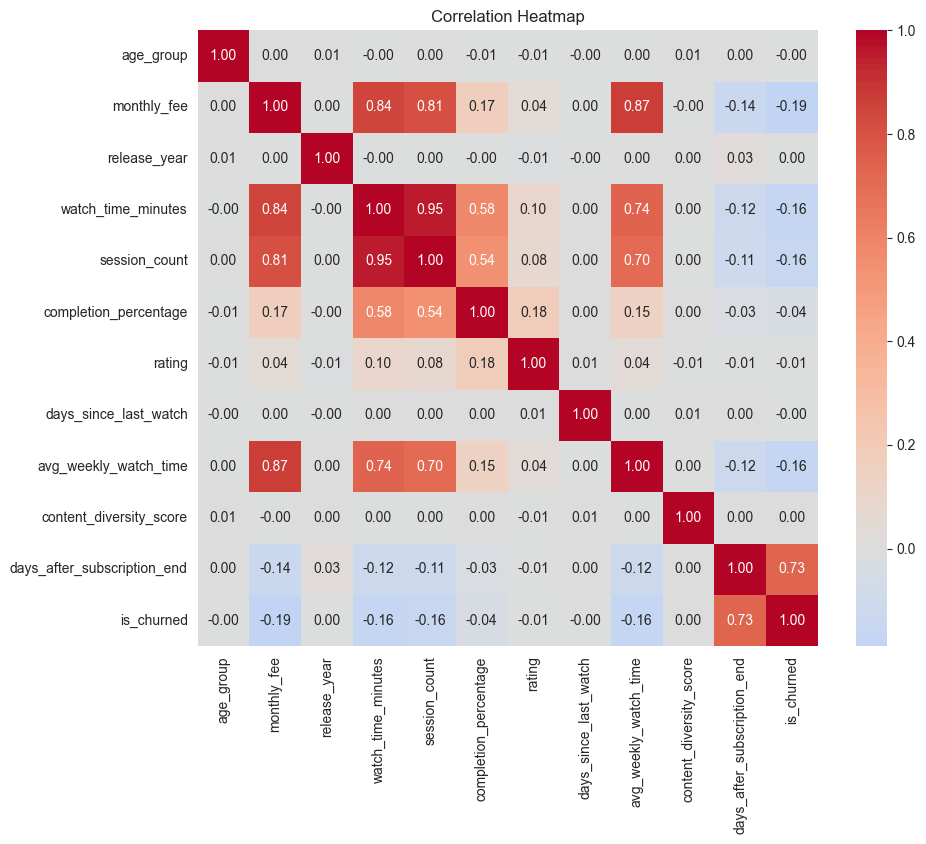

In [63]:
numeric_df = df_clean.select_dtypes(include="number")
numeric_df = numeric_df.copy()
numeric_df["is_churned"] = (df_clean["churn_status"] == "Cancelled").astype(int)
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 5.6 Valuable Customer Segments
Combining variables to find specific high-value or high-risk segments.

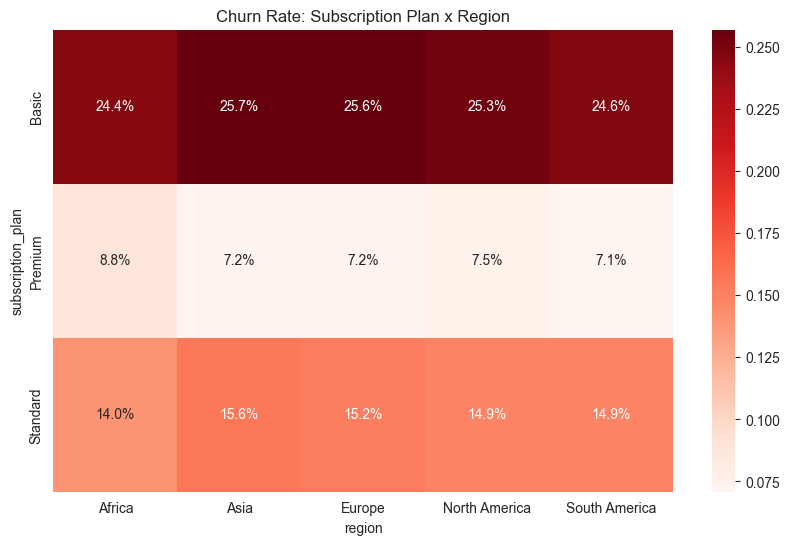

In [64]:
segment = (
    df_clean.groupby(["subscription_plan", "region"])["churn_status"]
    .value_counts(normalize=True)
    .unstack()["Cancelled"]
    .unstack()
)

plt.figure(figsize=(10, 6))
sns.heatmap(segment, annot=True, fmt=".1%", cmap="Reds")
plt.title("Churn Rate: Subscription Plan x Region")
plt.show()

# 6. SQL Analysis
Re-running key questions as SQL queries against the cleaned dataset.

In [65]:
import sqlite3

conn = sqlite3.connect(":memory:")
df_clean.to_sql("netflix", conn, index=False, if_exists="replace")

# quick sanity check
pd.read_sql("SELECT COUNT(*) AS row_count FROM netflix", conn)

,row_count
0,50000


## 6.1 Overall Churn Rate

In [66]:
query = """
SELECT
    churn_status,
    COUNT(*) AS customers,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM netflix), 2) AS pct
FROM netflix
GROUP BY churn_status
"""
pd.read_sql(query, conn)

,churn_status,customers,pct
0,Active,41391,82.78
1,Cancelled,8609,17.22


## 6.2 Churn Rate by Plan and Region

In [67]:
query = """
SELECT
    subscription_plan,
    region,
    COUNT(*) AS customers,
    ROUND(100.0 * SUM(CASE WHEN churn_status = 'Cancelled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM netflix
GROUP BY subscription_plan, region
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,subscription_plan,region,customers,churn_rate_pct
0,Basic,Asia,3957,25.68
1,Basic,Europe,6063,25.61
2,Basic,North America,4071,25.25
3,Basic,South America,1992,24.65
4,Basic,Africa,3948,24.44
5,Standard,Asia,3459,15.55
6,Standard,Europe,5301,15.22
7,Standard,North America,3500,14.91
8,Standard,South America,1669,14.86
9,Standard,Africa,3490,14.04


## 6.3 Average Engagement by Churn Status

In [68]:
query = """
SELECT
    churn_status,
    ROUND(AVG(watch_time_minutes), 1) AS avg_watch_time,
    ROUND(AVG(session_count), 1) AS avg_sessions,
    ROUND(AVG(completion_percentage), 1) AS avg_completion,
    ROUND(AVG(days_since_last_watch), 1) AS avg_days_since_watch
FROM netflix
GROUP BY churn_status
"""
pd.read_sql(query, conn)

,churn_status,avg_watch_time,avg_sessions,avg_completion,avg_days_since_watch
0,Active,87.1,2.4,92.1,29.9
1,Cancelled,75.1,2.0,91.0,29.9


## 6.4 Most-Watched Genres per Plan

In [69]:
query = """
SELECT
    subscription_plan,
    genre,
    COUNT(*) AS views
FROM netflix
GROUP BY subscription_plan, genre
ORDER BY subscription_plan, views DESC
"""
genre_by_plan = pd.read_sql(query, conn)

# keep only the top 3 genres per plan
genre_by_plan.groupby("subscription_plan").head(3)

,subscription_plan,genre,views
0,Basic,Thriller,2615
1,Basic,Sci-Fi,2526
2,Basic,Animation,2523
8,Premium,Drama,1618
9,Premium,Thriller,1604
10,Premium,Animation,1599
16,Standard,Drama,2297
17,Standard,Romance,2234
18,Standard,Documentary,2222


## 6.5 High-Value Customer Segments
Customers on higher-tier plans with strong engagement and low churn risk.

In [70]:
query = """
SELECT
    subscription_plan,
    region,
    COUNT(*) AS customers,
    ROUND(AVG(monthly_fee), 2) AS avg_fee,
    ROUND(AVG(avg_weekly_watch_time), 1) AS avg_weekly_watch,
    ROUND(100.0 * SUM(CASE WHEN churn_status = 'Cancelled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM netflix
GROUP BY subscription_plan, region
HAVING customers >= 100
ORDER BY avg_fee DESC, churn_rate_pct ASC
"""
pd.read_sql(query, conn)

,subscription_plan,region,customers,avg_fee,avg_weekly_watch,churn_rate_pct
0,Premium,South America,1270,17.99,359.5,7.09
1,Premium,Asia,2500,17.99,360.3,7.20
2,Premium,Europe,3674,17.99,359.7,7.21
3,Premium,North America,2601,17.99,359.0,7.50
4,Premium,Africa,2505,17.99,359.5,8.82
5,Standard,Africa,3490,13.99,269.7,14.04
6,Standard,South America,1669,13.99,269.1,14.86
7,Standard,North America,3500,13.99,269.3,14.91
8,Standard,Europe,5301,13.99,269.5,15.22
9,Standard,Asia,3459,13.99,270.5,15.55
